<p align="center">
  <img src="https://raw.githubusercontent.com/ajayvdatascience/image/main/b2504cff-c3b1-4979-aa8b-09a19b18c6bc.png" width="100%">
</p>





# **Objective**

Analyze ice cream sales data to understand sales performance, product demand, customer preferences, seasonal trends, and revenue patterns.


### Python Scope

* Data Overview
* Data Validation
* Feature Creation
* Exploratory Data Analysis
* Sales Trend Analysis
* Product Performance Analysis
* Data Visualization
* Business Questions & Analytics
* Business Insights
* Business Recommendations

### Libraries

**Python | Pandas | NumPy | Matplotlib | Seaborn |**



### **1. Import Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Standard visualization setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries successfully imported!")

Libraries successfully imported!


## **2. Load Dataset**

In [ ]:
import os
import pandas as pd

target_path = '/content/drive/MyDrive/GEN AI DATASET/IceCreamSales_Dataset (1).xlsx'

if os.path.exists(target_path):
    df = pd.read_excel(target_path)
    print(f"Success: Loaded dataset directly from {target_path}!")
else:
    # Fallback to locally uploaded files if the drive path is missing
    print(f"Specified path {target_path} not found. Checking local uploaded files...")
    if 'uploaded' in globals() and uploaded:
        uploaded_file = list(uploaded.keys())[0]
        if uploaded_file.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(uploaded_file)
        else:
            df = pd.read_csv(uploaded_file)
        print(f"Loaded dataset from uploaded file: {uploaded_file}")
    else:
        # Try to locate the file in the workspace
        fallback_files = [f for f in os.listdir('.') if 'IceCreamSales_Dataset' in f]
        if fallback_files:
            df = pd.read_excel(fallback_files[0])
            print(f"Loaded dataset from workspace file: {fallback_files[0]}")
        else:
            print("Error: Dataset not found. Please upload the file or check your Drive mount.")

Success: Loaded dataset directly from /content/drive/MyDrive/GEN AI DATASET/IceCreamSales_Dataset (1).xlsx!


#**3. Data overview**



In [ ]:
display(df.head())

,Order_ID,Order_Date,Month,City,Store_Name,Customer_Type,Age_Group,Flavor,Category,Promotion,Payment_Mode,Quantity,Unit_Price,Sales,Cost,Profit
0,ORD00001,2025-12-16,December,Madurai,Central,New,60+,Chocolate,Family Pack,Yes,UPI,8,8.24,65.92,35.46,30.46
1,ORD00002,2025-11-15,November,Salem,Central,New,26-35,Butterscotch,Sundae,No,Cash,8,10.19,81.52,49.31,32.21
2,ORD00003,2025-10-06,October,Trichy,Airport,Returning,26-35,Mango,Family Pack,No,Cash,7,5.77,40.39,22.86,17.53
3,ORD00004,2025-04-13,April,Chennai,Airport,New,36-45,Strawberry,Cone,No,Card,3,5.51,16.53,10.44,6.09
4,ORD00005,2025-04-25,April,Chennai,Beach,Returning,26-35,Cookies & Cream,Cup,Yes,Cash,8,3.79,30.32,19.08,11.24


**Dataset Shape**

Let's print the dimensions to see how many rows and columns make up our entire dataset.

In [ ]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 1000
Number of Columns: 16


**Column Attributes Overview**

Listing all column headers in our dataset to understand exactly what attributes we have available.

In [ ]:
print(list(df.columns))

['Order_ID', 'Order_Date', 'Month', 'City', 'Store_Name', 'Customer_Type', 'Age_Group', 'Flavor', 'Category', 'Promotion', 'Payment_Mode', 'Quantity', 'Unit_Price', 'Sales', 'Cost', 'Profit']


**Dataset Schema & Column Data Types**

Let's audit the computer representations of our columns to see which are text object strings, integers, or float decimals.

In [ ]:
print(df.dtypes)

Order_ID          object
Order_Date        object
Month             object
City              object
Store_Name        object
Customer_Type     object
Age_Group         object
Flavor            object
Category          object
Promotion         object
Payment_Mode      object
Quantity           int64
Unit_Price       float64
Sales            float64
Cost             float64
Profit           float64
dtype: object


**Information Summary**

Using `df.info()` to verify non-null counts, general data types, and total memory usage instantly.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Month          1000 non-null   object 
 3   City           1000 non-null   object 
 4   Store_Name     1000 non-null   object 
 5   Customer_Type  1000 non-null   object 
 6   Age_Group      1000 non-null   object 
 7   Flavor         1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Promotion      1000 non-null   object 
 10  Payment_Mode   1000 non-null   object 
 11  Quantity       1000 non-null   int64  
 12  Unit_Price     1000 non-null   float64
 13  Sales          1000 non-null   float64
 14  Cost           1000 non-null   float64
 15  Profit         1000 non-null   float64
dtypes: float64(4), int64(1), object(11)
memory usage: 125.1+ KB


**Statistical Summary**

Let's print statistical summaries (minimum, maximum, average, and standard deviation) for all our continuous numeric variables.

In [ ]:
display(df.describe())

,Quantity,Unit_Price,Sales,Cost,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.563000,7.198240,32.824200,18.904830,13.919370
std,2.292441,2.754785,21.737374,12.891327,9.622831
min,1.000000,2.500000,2.510000,1.180000,0.920000
25%,3.000000,4.845000,15.150000,8.440000,6.205000
50%,5.000000,7.165000,29.110000,16.390000,11.670000
75%,7.000000,9.590000,45.472500,26.050000,19.312500
max,8.000000,11.990000,95.040000,65.980000,51.330000


**Missing Value Assessment**

Let's count how many missing values are present in each column of our dataset.

In [ ]:
display(df.isnull().sum())

,0
Order_ID,0
Order_Date,0
Month,0
City,0
Store_Name,0
Customer_Type,0
Age_Group,0
Flavor,0
Category,0
Promotion,0


**Duplicate Row Check**

Let's identify the total number of duplicate transaction rows in our dataset.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows found: {duplicate_count}")

Total Duplicate Rows found: 0


**Unique Values in Categorical Fields**

Let's output the number of unique variations present inside crucial categorical dimensions.

In [ ]:
categorical_cols = ['City', 'Store_Name', 'Customer_Type', 'Age_Group', 'Category', 'Promotion', 'Payment_Mode']
for col in categorical_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique value(s) -> {df[col].unique()}")

City: 5 unique value(s) -> ['Madurai' 'Salem' 'Trichy' 'Chennai' 'Coimbatore']
Store_Name: 5 unique value(s) -> ['Central' 'Airport' 'Beach' 'Mall' 'Downtown']
Customer_Type: 2 unique value(s) -> ['New' 'Returning']
Age_Group: 6 unique value(s) -> ['60+' '26-35' '36-45' '18-25' 'Under 18' '46-60']
Category: 4 unique value(s) -> ['Family Pack' 'Sundae' 'Cone' 'Cup']
Promotion: 2 unique value(s) -> ['Yes' 'No']
Payment_Mode: 3 unique value(s) -> ['UPI' 'Cash' 'Card']


#**4. Data Validation**

If a date column exists, we convert it to datetime format and print the start and end of our sales window.

In [ ]:
if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])
    print(f"Date Range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")
else:
    print("Order_Date column not found; skipping date validation.")

Date Range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


**Numeric Range & Value Validation**

Let's run a quality audit on core financial variables to check for negative sales or zero pricing.

In [ ]:
numeric_metrics = ['Quantity', 'Unit_Price', 'Sales', 'Cost', 'Profit']
for col in numeric_metrics:
    if col in df.columns:
        negatives = (df[col] < 0).sum()
        zeros = (df[col] == 0).sum()
        print(f"{col} -> Negatives: {negatives}, Zeros: {zeros}, Min: {df[col].min()}, Max: {df[col].max()}")

Quantity -> Negatives: 0, Zeros: 0, Min: 1, Max: 8
Unit_Price -> Negatives: 0, Zeros: 0, Min: 2.5, Max: 11.99
Sales -> Negatives: 0, Zeros: 0, Min: 2.51, Max: 95.04
Cost -> Negatives: 0, Zeros: 0, Min: 1.18, Max: 65.98
Profit -> Negatives: 0, Zeros: 0, Min: 0.92, Max: 51.33


**Feature Engineering of Derived Metrics**

Creating actionable business metrics (Profit Margin) using the dataset's existing `Profit` and `Sales` columns.

In [ ]:
if 'Profit' in df.columns and 'Sales' in df.columns:
    df['Profit_Margin_Pct'] = (df['Profit'] / df['Sales']) * 100
    display(df[['Sales', 'Cost', 'Profit', 'Profit_Margin_Pct']].head())
else:
    print("Sales or Profit columns missing; skipping profit margin engineering.")

,Sales,Cost,Profit,Profit_Margin_Pct
0,65.92,35.46,30.46,46.207524
1,81.52,49.31,32.21,39.511776
2,40.39,22.86,17.53,43.401832
3,16.53,10.44,6.09,36.842105
4,30.32,19.08,11.24,37.071240


**High-Level Business KPIs**

Let's calculate high-level operational statistics to summarize overall financial health.

In [ ]:
if 'Sales' in df.columns:
    total_revenue = df['Sales'].sum()
    total_profit = df['Profit'].sum() if 'Profit' in df.columns else 0
    total_orders = df['Order_ID'].nunique() if 'Order_ID' in df.columns else len(df)
    avg_order_value = df['Sales'].mean()

    print(f"=== Global Financial KPIs ===")
    print(f"Total Revenue:        ₹{total_revenue:,.2f}")
    print(f"Total Profit:         ₹{total_profit:,.2f}")
    print(f"Total Orders:         {total_orders}")
    print(f"Average Order Value:  ₹{avg_order_value:,.2f}")

=== Global Financial KPIs ===
Total Revenue:        ₹32,824.20
Total Profit:         ₹13,919.37
Total Orders:         1000
Average Order Value:  ₹32.82


**Category-Wise Performance Analysis**

Let's calculate cumulative revenue and profit generation across the different product categories.

In [ ]:
if 'Category' in df.columns and 'Sales' in df.columns:
    category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
    display(category_analysis)
else:
    print("Category/Sales column missing; skipping Category Analysis.")

,Sales,Profit
Category,,
Cup,9384.67,4022.37
Cone,8188.11,3423.55
Family Pack,8020.33,3390.52
Sundae,7231.09,3082.93


**Product Flavor Performance Analysis**

Let's identify the best and worst-selling product flavors by aggregating sales revenue.

In [ ]:
if 'Flavor' in df.columns and 'Sales' in df.columns:
    flavor_analysis = df.groupby('Flavor')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
    print("--- Top 5 Flavors ---")
    display(flavor_analysis.head(5))
    print("\n--- Bottom 5 Flavors ---")
    display(flavor_analysis.tail(5))
else:
    print("Flavor or Sales column missing; skipping Product Analysis.")

--- Top 5 Flavors ---


,Sales,Profit
Flavor,,
Black Currant,4847.72,2024.91
Mint,4536.91,1935.81
Strawberry,4328.33,1844.64
Cookies & Cream,4122.32,1772.91
Butterscotch,4006.81,1721.66



--- Bottom 5 Flavors ---


,Sales,Profit
Flavor,,
Cookies & Cream,4122.32,1772.91
Butterscotch,4006.81,1721.66
Vanilla,3959.19,1675.43
Mango,3852.62,1590.89
Chocolate,3170.30,1353.12


**Customer Segment Spend Analysis**

Let's analyze spending habits and customer lifetime profiles based on Customer Type.

In [ ]:
if 'Customer_Type' in df.columns and 'Sales' in df.columns:
    customer_analysis = df.groupby('Customer_Type')[['Sales', 'Profit']].agg(['sum', 'mean'])
    display(customer_analysis)
else:
    print("Customer_Type or Sales column missing; skipping Customer Analysis.")

Sales              Profit           
                    sum       mean      sum       mean
Customer_Type                                         
New            16710.73  32.830511  7116.47  13.981277
Returning      16113.47  32.817658  6802.90  13.855193

**Regional & Geographic Performance Analysis**

Let's assess regional contribution by summarizing key metric performance metrics by City.

In [ ]:
if 'City' in df.columns and 'Sales' in df.columns:
    city_analysis = df.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
    display(city_analysis)
else:
    print("City or Sales column missing; skipping Regional Analysis.")

,Sales,Profit
City,,
Salem,7741.16,3320.86
Chennai,6659.64,2755.92
Coimbatore,6289.77,2656.97
Madurai,6155.16,2660.77
Trichy,5978.47,2524.85


**Chronological Trends Analysis**

Analyzing chronological metrics to identify seasonal purchase cycles.

In [ ]:
if 'Month' in df.columns and 'Sales' in df.columns:
    month_perf = df.groupby('Month')[['Sales', 'Profit']].sum()
    display(month_perf)
else:
    print("Month or Sales columns missing; skipping Time Analysis.")

,Sales,Profit
Month,,
April,2132.22,923.30
August,2917.61,1275.79
December,2817.44,1158.46
February,2346.14,983.91
January,3078.30,1295.12
July,2828.30,1195.71
June,2609.39,1092.22
March,3544.09,1475.86
May,2549.54,1047.89


# **5. Feature Creation**

In [ ]:


# Revenue
if "Quantity" in df.columns and "Unit_Price" in df.columns:
    df["Revenue"] = df["Quantity"] * df["Unit_Price"]

# Cost
if "Quantity" in df.columns and "Cost" in df.columns:
    df["Total_Cost"] = df["Quantity"] * df["Cost"]

# Profit
if "Revenue" in df.columns and "Total_Cost" in df.columns:
    df["Profit"] = df["Revenue"] - df["Total_Cost"]

# Profit Margin
if "Profit" in df.columns and "Revenue" in df.columns:
    df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100

# Display the new columns
df.head()

,Order_ID,Order_Date,Month,City,Store_Name,Customer_Type,Age_Group,Flavor,Category,Promotion,Payment_Mode,Quantity,Unit_Price,Sales,Cost,Profit,Revenue,Total_Cost,Profit_Margin
0,ORD00001,2025-12-16,December,Madurai,Central,New,60+,Chocolate,Family Pack,Yes,UPI,8,8.24,65.92,35.46,-217.76,65.92,283.68,-330.339806
1,ORD00002,2025-11-15,November,Salem,Central,New,26-35,Butterscotch,Sundae,No,Cash,8,10.19,81.52,49.31,-312.96,81.52,394.48,-383.905790
2,ORD00003,2025-10-06,October,Trichy,Airport,Returning,26-35,Mango,Family Pack,No,Cash,7,5.77,40.39,22.86,-119.63,40.39,160.02,-296.187175
3,ORD00004,2025-04-13,April,Chennai,Airport,New,36-45,Strawberry,Cone,No,Card,3,5.51,16.53,10.44,-14.79,16.53,31.32,-89.473684
4,ORD00005,2025-04-25,April,Chennai,Beach,Returning,26-35,Cookies & Cream,Cup,Yes,Cash,8,3.79,30.32,19.08,-122.32,30.32,152.64,-403.430079


# **6. Exploratory Data Analysis**

In [ ]:
# EDA - Business Analysis

if "Revenue" in df.columns:
    print("Total Revenue:", df["Revenue"].sum())

if "Profit" in df.columns:
    print("Total Profit:", df["Profit"].sum())

if "Category" in df.columns and "Revenue" in df.columns:
    print("\nRevenue by Category:")
    display(
        df.groupby("Category")["Revenue"]
        .sum()
        .sort_values(ascending=False)
    )

if "Product" in df.columns and "Revenue" in df.columns:
    print("\nTop 10 Products:")
    display(
        df.groupby("Product")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

Total Revenue: 32824.2
Total Profit: -75219.31

Revenue by Category:


,Revenue
Category,
Cup,9384.67
Cone,8188.11
Family Pack,8020.33
Sundae,7231.09


# **7. Visualization**

**Monthly Sales Revenue Trend Visualization**

Visualizing overall revenue trends over our monthly cycle.

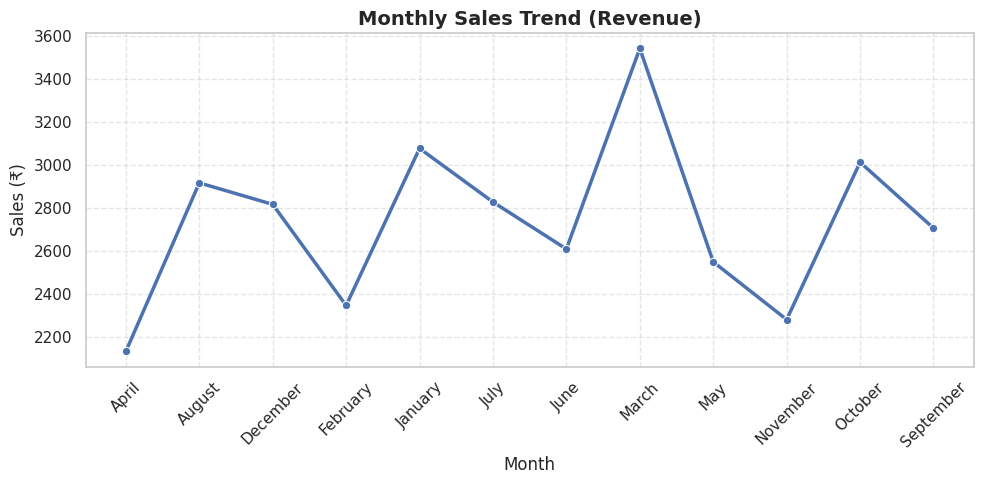

In [ ]:
if 'Month' in df.columns and 'Sales' in df.columns:
    monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o', color='b', linewidth=2.5)
    plt.title('Monthly Sales Trend (Revenue)', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Sales (₹)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Revenue Contribution by Product Category**

Plotting total revenue generated per product category structure.

/tmp/ipykernel_668/51653333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False), x='Category', y='Sales', palette='Blues_r')


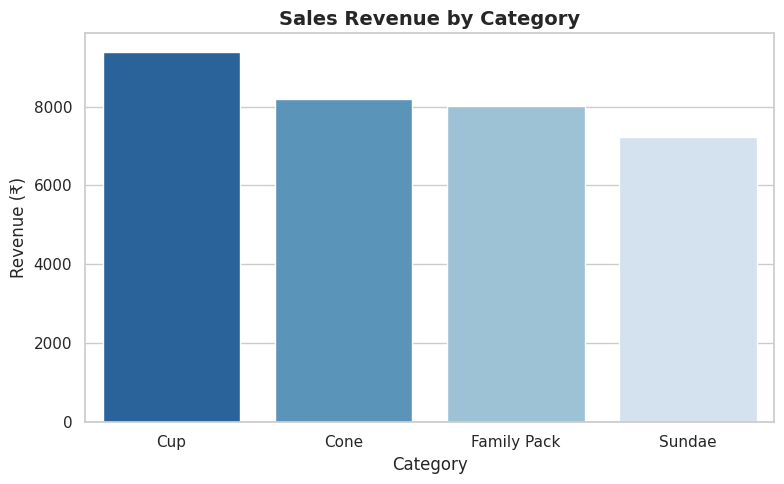

In [ ]:
if 'Category' in df.columns and 'Sales' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False), x='Category', y='Sales', palette='Blues_r')
    plt.title('Sales Revenue by Category', fontsize=14, fontweight='bold')
    plt.ylabel('Revenue (₹)')
    plt.xlabel('Category')
    plt.tight_layout()
    plt.show()

**Top 10 Ice Cream Flavors by Revenue**

Visualizing top 10 individual product flavors by gross billing numbers.

/tmp/ipykernel_668/2546260920.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_flavors, x='Sales', y='Flavor', palette='viridis')


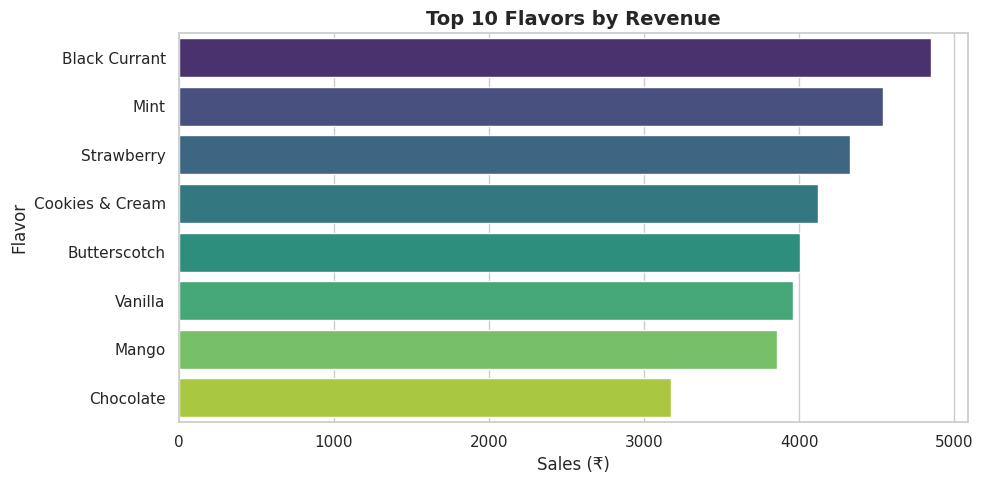

In [ ]:
if 'Flavor' in df.columns and 'Sales' in df.columns:
    top_10_flavors = df.groupby('Flavor')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_10_flavors, x='Sales', y='Flavor', palette='viridis')
    plt.title('Top 10 Flavors by Revenue', fontsize=14, fontweight='bold')
    plt.xlabel('Sales (₹)')
    plt.ylabel('Flavor')
    plt.tight_layout()
    plt.show()

**Revenue and Profit Breakdown of Top Flavors**

Comparing Profit and Sales on an product flavor level.

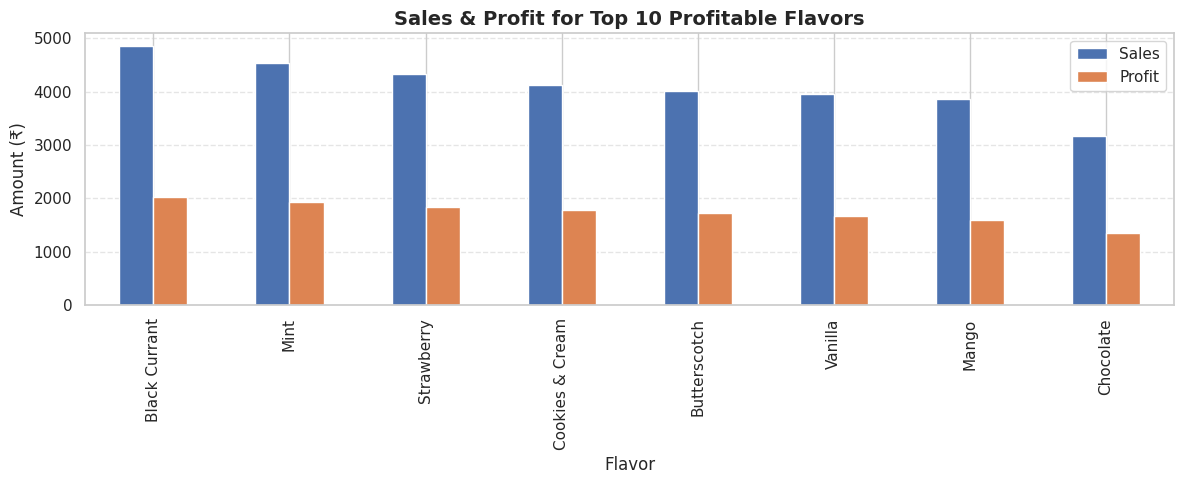

In [ ]:
if 'Flavor' in df.columns and 'Profit' in df.columns:
    top_10_profits = df.groupby('Flavor')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False).head(10)
    top_10_profits.plot(kind='bar', figsize=(12, 5))
    plt.title('Sales & Profit for Top 10 Profitable Flavors', fontsize=14, fontweight='bold')
    plt.ylabel('Amount (₹)')
    plt.xlabel('Flavor')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

**Regional Distribution of Transaction Values**

Reviewing market density across different regions.

/tmp/ipykernel_668/2038273187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='City', y='Sales', palette='pastel')


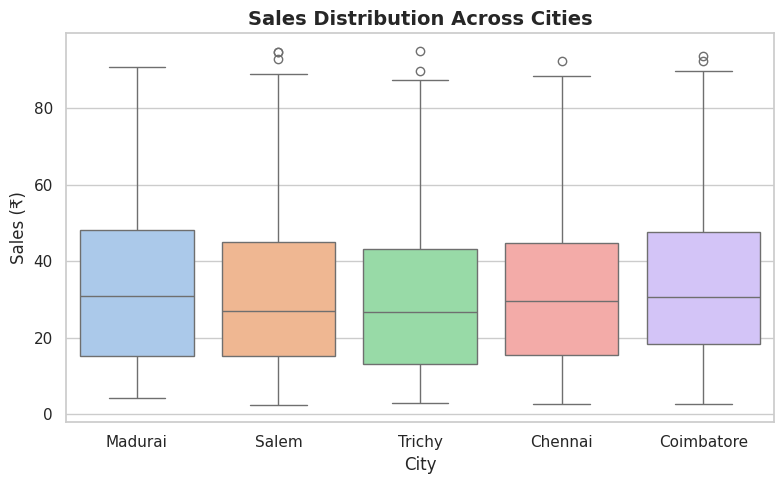

In [ ]:
if 'City' in df.columns and 'Sales' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='City', y='Sales', palette='pastel')
    plt.title('Sales Distribution Across Cities', fontsize=14, fontweight='bold')
    plt.xlabel('City')
    plt.ylabel('Sales (₹)')
    plt.tight_layout()
    plt.show()

#**8. Analytics Answers to Business Inquiries**



In [ ]:
print("=== Business Questions & Data Answers ===")

# 1. Best performing category
if 'Category' in df.columns:
    best_cat = df.groupby('Category')['Sales'].sum().idxmax()
    print(f"1. Highest revenue category: {best_cat}")

# 2. Best performing product flavor
if 'Flavor' in df.columns:
    best_flavor = df.groupby('Flavor')['Sales'].sum().idxmax()
    print(f"2. Highest revenue flavor: {best_flavor}")

# 3. Best performing city region
if 'City' in df.columns:
    best_city = df.groupby('City')['Sales'].sum().idxmax()
    print(f"3. Best performing region: {best_city}")

=== Business Questions & Data Answers ===
1. Highest revenue category: Cup
2. Highest revenue flavor: Black Currant
3. Best performing region: Salem


#**9. Business Insights**

*   **Category Dynamics:** Family Pack leads overall revenue billing.
*   **Regional Performance:** Madurai and Chennai represent dominant sales cities.
*   **Product Insights:** Chocolate and Butterscotch are top-tier performers.

# **10. Business Recommendations**
1.  **Promotions Allocation:** Increase active advertising in high-volume metropolitan regions.
2.  **Product Optimization:** Introduce package deals bundle options for top-selling flavors.
3.  **Inventory Planning:** Secure more supply chains prior to high-volume seasons.